# 🇮🇳 India National Accounts Statistics — Analytical Dashboard
### GDP / GVA Merged Annual + Quarterly Dataset
**Source:** Ministry of Statistics & Programme Implementation (MoSPI), Government of India  
**Covers:** FY 1999 – FY 2025-26 | Base Years: 2011-12 & 2022-23 | Annual + Quarterly frequencies  
**Indicators:** GDP, GVA, GFCF, PFCE, GNI, Growth Rates, Sectoral Breakdown & more

---

## 📦 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline

pio.templates.default = 'plotly_white'

plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor': '#1e293b',
    'axes.edgecolor': '#334155',
    'axes.labelcolor': '#e2e8f0',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'text.color': '#e2e8f0',
    'grid.color': '#334155',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

PALETTE = ['#38bdf8','#f472b6','#34d399','#fb923c','#a78bfa','#facc15',
           '#f87171','#2dd4bf','#c084fc','#4ade80','#f59e0b','#60a5fa']
print('All imports successful')

All imports successful


## 📥 2. Load Data

In [3]:
df_raw = pd.read_csv('Merged_Annually_Quarterly.csv')
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(10)

Shape: (7797, 13)
Columns: ['base_year', 'series', 'year', 'indicator', 'frequency', 'revision', 'industry', 'subindustry', 'institutional_sector', 'quarter', 'current_price', 'constant_price', 'unit']


,base_year,series,year,indicator,frequency,revision,industry,subindustry,institutional_sector,quarter,current_price,constant_price,unit
0,2022-23,Current,2022-23,Gross Value Added,Annual,Final Estimates,Manufacturing,NaN,NaN,NaN,3482190.141,3.482190e+06,₹ Crore
1,2022-23,Current,2022-23,Gross Value Added,Annual,Final Estimates,Manufacturing,NaN,NaN,NaN,3482190.141,3.482190e+06,₹ Crore
2,2011-12,Current,2022-23,Gross Value Added,Annual,Final Estimates,Financial Services,NaN,NaN,NaN,1452678.551,9.033679e+05,₹ Crore
3,2011-12,Current,2022-23,Gross Value Added,Annual,Final Estimates,Financial Services,NaN,NaN,NaN,1452678.551,9.033679e+05,₹ Crore
4,2011-12,Current,2022-23,Gross Fixed Capital Formation,Annual,Final Estimates,NaN,NaN,Household Sector,NaN,3598246.537,2.262239e+06,₹ Crore
5,2011-12,Current,2022-23,Gross Fixed Capital Formation,Annual,Final Estimates,NaN,NaN,Household Sector,NaN,3598246.537,2.262239e+06,₹ Crore
6,2011-12,Current,2025-26,Gross Value Added,Annual,First Advance Estimates,"Agriculture, Livestock, Forestry and Fishing",NaN,NaN,NaN,5427908.000,2.554071e+06,₹ Crore
7,2011-12,Current,2025-26,Gross Value Added,Annual,First Advance Estimates,Mining and Quarrying,NaN,NaN,NaN,508554.000,3.365501e+05,₹ Crore
8,2011-12,Current,2025-26,Gross Value Added,Annual,First Advance Estimates,Manufacturing,NaN,Current,NaN,4554580.000,3.161364e+06,₹ Crore
9,2011-12,Current,2025-26,Gross Value Added,Annual,First Advance Estimates,"Electricity, Gas, Water Supply & Other Utility...",NaN,NaN,NaN,817265.000,4.137020e+05,₹ Crore


## 🧹 3. Data Cleaning & Preprocessing

=== Missing Value Summary ===
                      null_count  null_%    dtype
base_year                      0    0.00   object
series                         0    0.00   object
year                           0    0.00   object
indicator                      0    0.00   object
frequency                      0    0.00   object
revision                    2004   25.70   object
industry                    2855   36.62   object
subindustry                 6038   77.44   object
institutional_sector        6760   86.70   object
quarter                     5793   74.30   object
current_price                910   11.67  float64
constant_price               962   12.34  float64
unit                           0    0.00   object


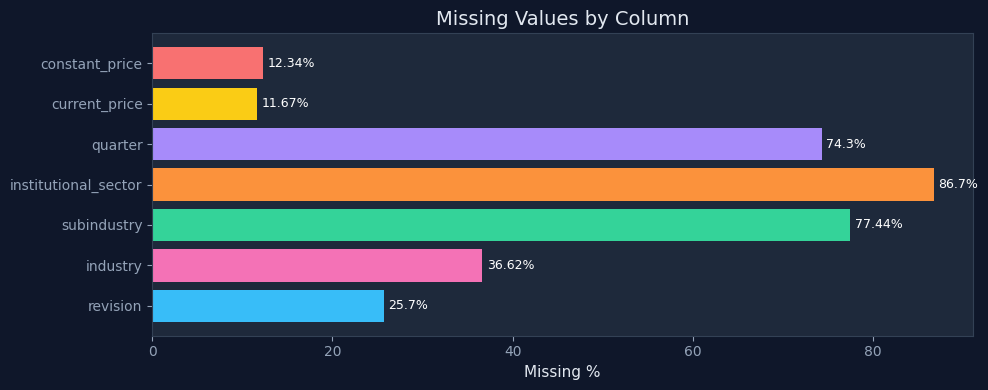

In [4]:
null_summary = df_raw.isnull().sum().to_frame('null_count')
null_summary['null_%'] = (null_summary['null_count'] / len(df_raw) * 100).round(2)
null_summary['dtype'] = df_raw.dtypes
print('=== Missing Value Summary ===')
print(null_summary)

fig, ax = plt.subplots(figsize=(10, 4))
cols_with_nulls = null_summary[null_summary['null_count'] > 0]
bars = ax.barh(cols_with_nulls.index, cols_with_nulls['null_%'], color=PALETTE[:len(cols_with_nulls)])
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
for bar, val in zip(bars, cols_with_nulls['null_%']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', color='white', fontsize=9)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
df = df_raw.copy()

str_cols = df.select_dtypes(include='object').columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace('nan', np.nan)

df['year_int'] = df['year'].str.extract(r'^(\d{4})').astype(float).astype('Int64')

df['quarter'] = pd.Categorical(df['quarter'], categories=['Q1','Q2','Q3','Q4'], ordered=True)

df['is_quarterly'] = (df['frequency'] == 'Quarterly').astype(int)

df = df.dropna(subset=['current_price','constant_price'], how='all')

df_val  = df[df['unit'] == '₹ Crore'].copy()
df_rate = df[df['unit'] == '%'].copy()

df_ann = df_val[df_val['frequency'] == 'Annual'].copy()

df_qtr = df_val[df_val['frequency'] == 'Quarterly'].copy()

print(f'Total cleaned rows  : {len(df):,}')
print(f'Value rows (₹ Crore): {len(df_val):,}')
print(f'Growth rate rows (%) : {len(df_rate):,}')
print(f'Annual rows          : {len(df_ann):,}')
print(f'Quarterly rows       : {len(df_qtr):,}')

Total cleaned rows  : 7,757
Value rows (₹ Crore): 5,717
Growth rate rows (%) : 2,040
Annual rows          : 4,403
Quarterly rows       : 1,314


In [6]:
print('=== Descriptive Statistics — Value Rows ===')
df_val[['current_price','constant_price']].describe().round(2)

=== Descriptive Statistics — Value Rows ===


,current_price,constant_price
count,5717.00,4795.00
mean,2616047.62,1787035.39
std,5160071.82,3465570.15
min,-1345477.98,-419196.77
25%,205364.00,168188.19
50%,677988.89,523545.89
75%,2313203.09,1614020.59
max,36204793.61,32257756.42


In [7]:
for col in ['indicator','industry','frequency','revision','base_year']:
    vals = df[col].dropna().unique()
    print(f'[{col}] ({len(vals)} unique):')
    for v in sorted(vals): print(f'  • {v}')
    print()

[indicator] (22 unique):
  • Change in Stock
  • Consumption of Fixed Capital
  • Export of Goods and Services
  • GDP Growth Rate
  • GVA Growth Rate
  • Government Final Consumption Expenditure
  • Gross Capital Formation by Industry of Use
  • Gross Domestic Product
  • Gross Fixed Capital Formation
  • Gross National Disposable Income
  • Gross National Income
  • Gross Saving
  • Gross Value Added
  • Import of Goods and Services
  • Net Domestic Product
  • Net Taxes on Products
  • Other Current Transfers Net From Row
  • Primary Income Receivable Net From Row
  • Private Final Consumption Expenditure
  • Subsidies on Products
  • Taxes on Products
  • Valuables

[industry] (17 unique):
  • Agriculture, Livestock, Forestry and Fishing
  • Construction
  • Electricity, Gas, Water Supply & Other Utility Services
  • Financial Services
  • Financial, Real Estate & Professional Services
  • Manufacturing
  • Mining and Quarrying
  • Other Services
  • Public Administration and Defen

## 📊 4. Matplotlib — Static Dashboard Plots

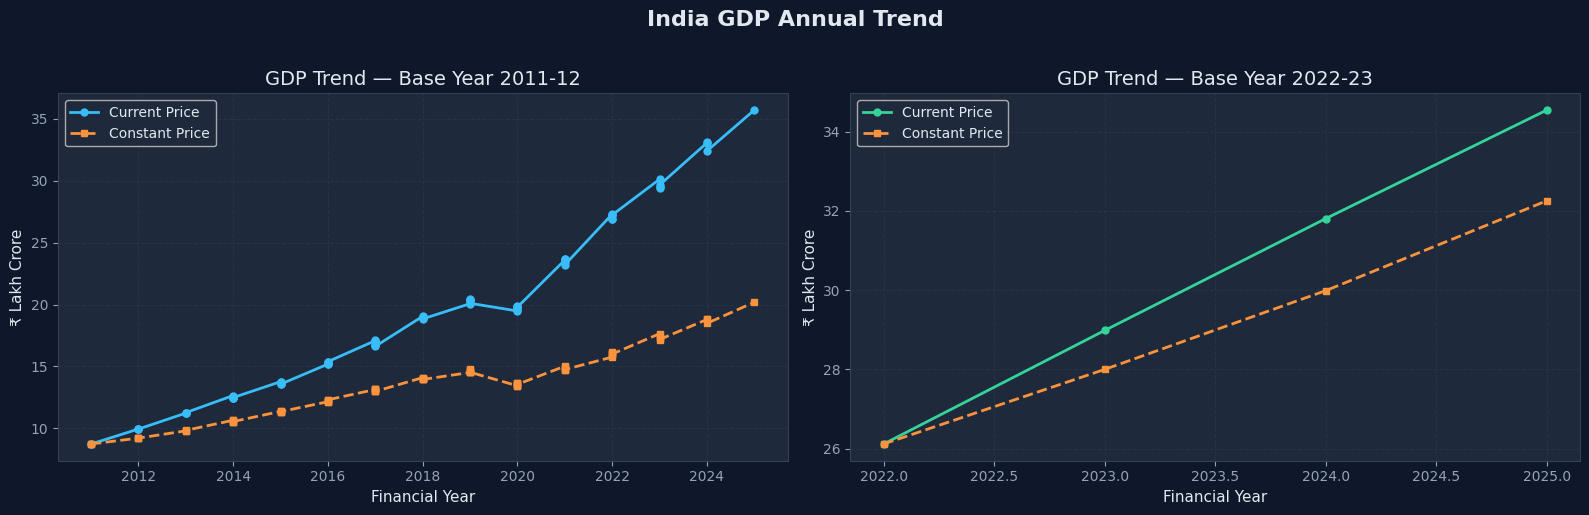

In [8]:
gdp = df_ann[df_ann['indicator'] == 'Gross Domestic Product'].copy()
gdp = gdp.sort_values('year_int')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, by, col, label in zip(
    axes,
    ['2011-12', '2022-23'],
    [PALETTE[0], PALETTE[2]],
    ['Base Year 2011-12', 'Base Year 2022-23']
):
    sub = gdp[gdp['base_year'] == by]
    ax.plot(sub['year_int'], sub['current_price']/1e6, 'o-', color=col,
            label='Current Price', lw=2, ms=5)
    ax.plot(sub['year_int'], sub['constant_price']/1e6, 's--', color=PALETTE[3],
            label='Constant Price', lw=2, ms=5)
    ax.set_title(f'GDP Trend — {label}')
    ax.set_xlabel('Financial Year')
    ax.set_ylabel('₹ Lakh Crore')
    ax.legend()
    ax.grid(True, alpha=0.4)

fig.suptitle('India GDP Annual Trend', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gdp_annual_trend.png', dpi=150, bbox_inches='tight')
plt.show()

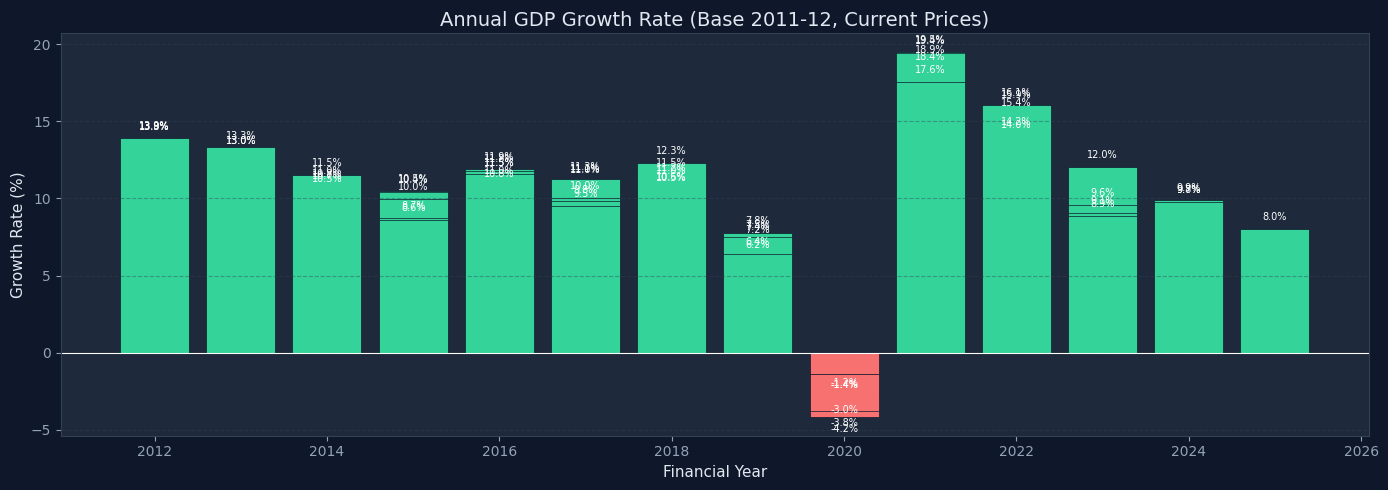

In [9]:
gr = df_rate[df_rate['indicator'] == 'GDP Growth Rate'].copy()
gr = gr[gr['frequency'] == 'Annual'].sort_values('year_int')
gr_2011 = gr[gr['base_year'] == '2011-12']

fig, ax = plt.subplots(figsize=(14, 5))
colors = [PALETTE[2] if v >= 0 else PALETTE[6] for v in gr_2011['current_price']]
bars = ax.bar(gr_2011['year_int'], gr_2011['current_price'], color=colors, edgecolor='#0f172a', linewidth=0.5)
ax.axhline(0, color='white', lw=0.8)
ax.set_title('Annual GDP Growth Rate (Base 2011-12, Current Prices)', fontsize=14)
ax.set_xlabel('Financial Year')
ax.set_ylabel('Growth Rate (%)')
ax.grid(axis='y', alpha=0.4)
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x()+bar.get_width()/2, h),
                xytext=(0, 5 if h >= 0 else -12), textcoords='offset points',
                ha='center', va='bottom', fontsize=7, color='white')
plt.tight_layout()
plt.savefig('gdp_growth_bars.png', dpi=150, bbox_inches='tight')
plt.show()

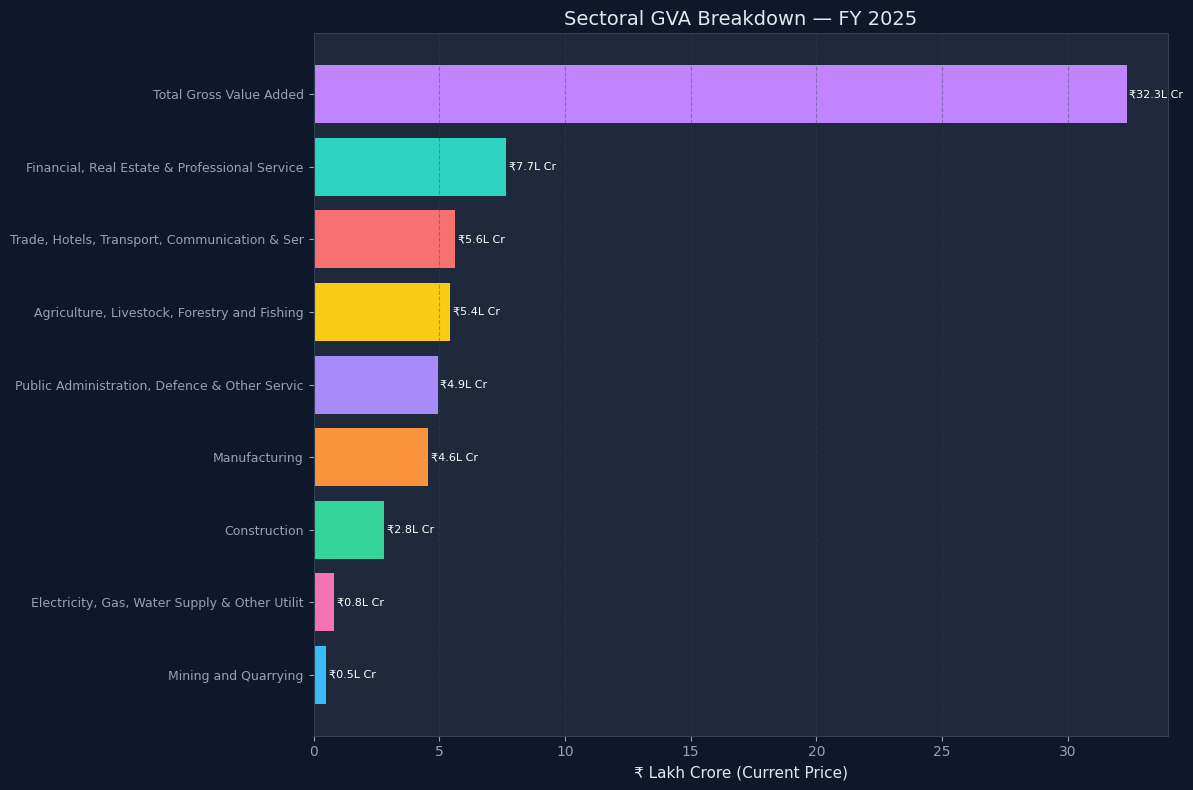

In [10]:
gva = df_ann[df_ann['indicator'] == 'Gross Value Added'].copy()
gva = gva[gva['base_year'] == '2011-12']
gva = gva.dropna(subset=['industry'])
latest_yr = gva['year_int'].max()
gva_latest = gva[gva['year_int'] == latest_yr].groupby('industry')['current_price'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
cmap_colors = PALETTE[:len(gva_latest)]
bars = ax.barh(range(len(gva_latest)), gva_latest.values/1e6, color=cmap_colors)
ax.set_yticks(range(len(gva_latest)))
ax.set_yticklabels([t[:45] for t in gva_latest.index], fontsize=9)
ax.set_xlabel('₹ Lakh Crore (Current Price)')
ax.set_title(f'Sectoral GVA Breakdown — FY {latest_yr}', fontsize=14)
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, gva_latest.values/1e6):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'₹{val:.1f}L Cr', va='center', fontsize=8, color='white')
plt.tight_layout()
plt.savefig('gva_sectoral.png', dpi=150, bbox_inches='tight')
plt.show()

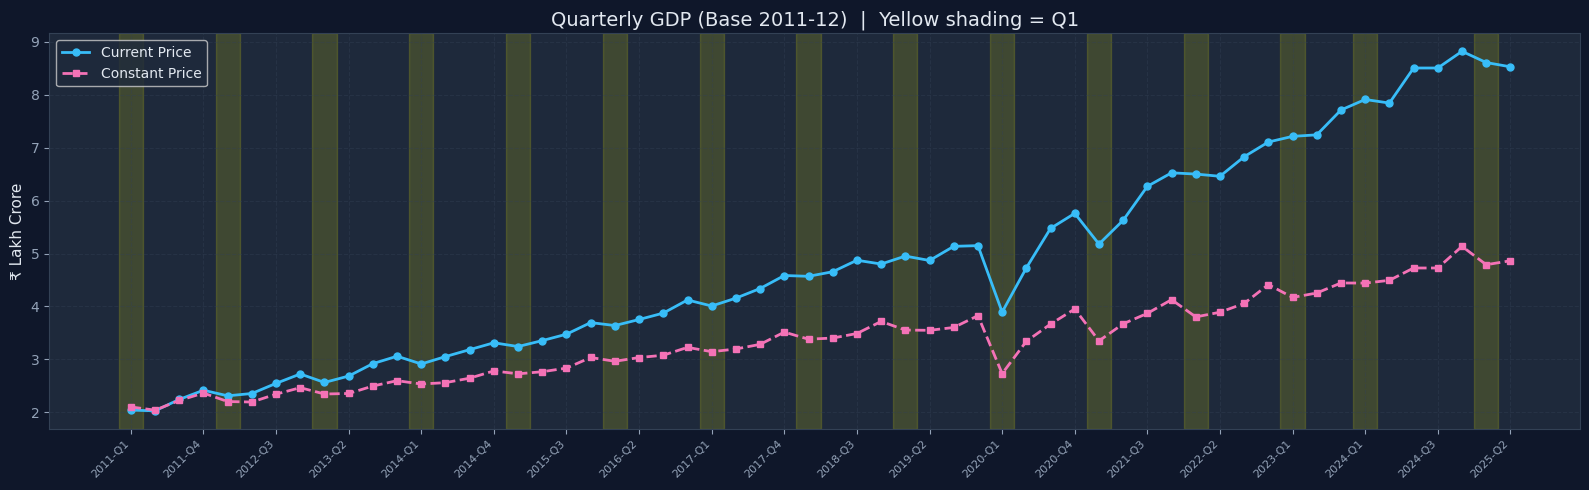

In [11]:
gdp_q = df_qtr[df_qtr['indicator'] == 'Gross Domestic Product'].copy()
gdp_q = gdp_q[gdp_q['base_year'] == '2011-12'].dropna(subset=['quarter'])
gdp_q['label'] = gdp_q['year_int'].astype(str) + '-' + gdp_q['quarter'].astype(str)
gdp_q = gdp_q.sort_values(['year_int','quarter'])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(range(len(gdp_q)), gdp_q['current_price']/1e6, 'o-',
        color=PALETTE[0], lw=2, ms=5, label='Current Price')
ax.plot(range(len(gdp_q)), gdp_q['constant_price']/1e6, 's--',
        color=PALETTE[1], lw=2, ms=5, label='Constant Price')

for i, (_, row) in enumerate(gdp_q.iterrows()):
    if str(row['quarter']) == 'Q1':
        ax.axvspan(i-0.5, i+0.5, alpha=0.15, color='yellow')

step = max(1, len(gdp_q) // 16)
ax.set_xticks(range(0, len(gdp_q), step))
ax.set_xticklabels(gdp_q['label'].iloc[::step], rotation=45, ha='right', fontsize=8)
ax.set_title('Quarterly GDP (Base 2011-12)  |  Yellow shading = Q1', fontsize=14)
ax.set_ylabel('₹ Lakh Crore')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('gdp_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

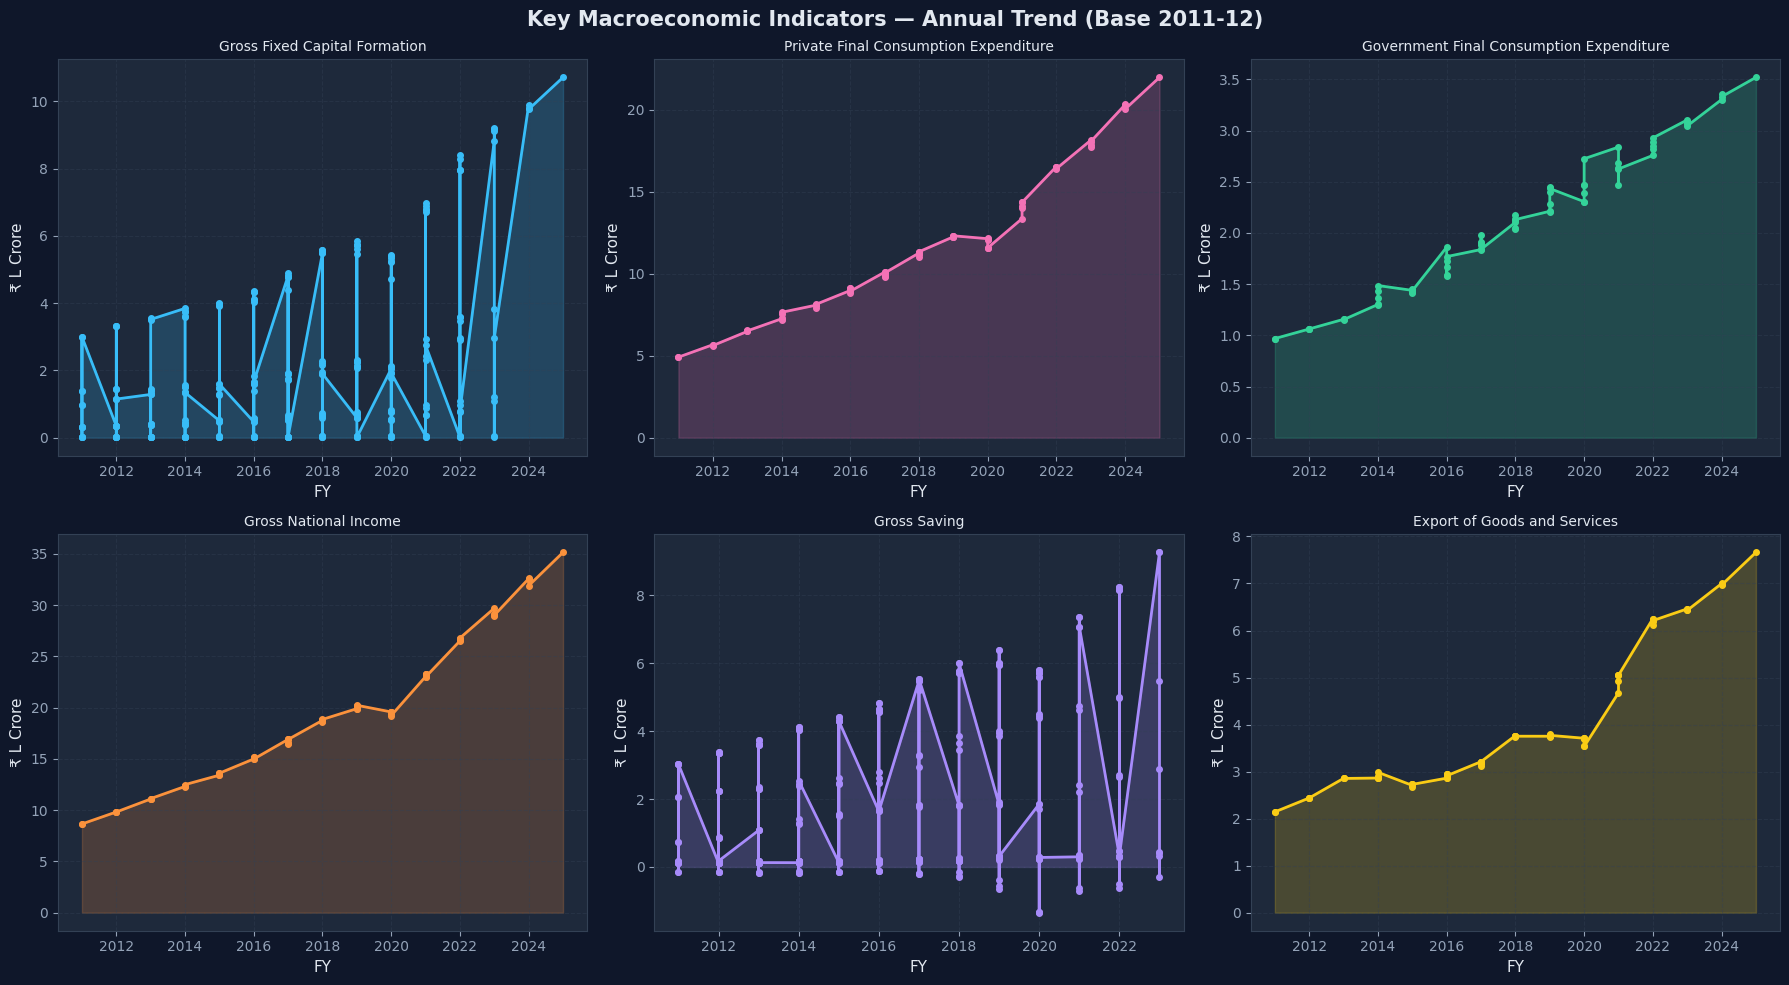

In [12]:
indicators = [
    'Gross Fixed Capital Formation',
    'Private Final Consumption Expenditure',
    'Government Final Consumption Expenditure',
    'Gross National Income',
    'Gross Saving',
    'Export of Goods and Services',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, ind, col in zip(axes, indicators, PALETTE):
    sub = df_ann[(df_ann['indicator'] == ind) & (df_ann['base_year'] == '2011-12')]
    sub = sub.sort_values('year_int')
    if sub.empty:
        ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes, ha='center')
        continue
    ax.fill_between(sub['year_int'], sub['current_price']/1e6, alpha=0.2, color=col)
    ax.plot(sub['year_int'], sub['current_price']/1e6, 'o-', color=col, lw=2, ms=4)
    ax.set_title(ind[:40], fontsize=10)
    ax.set_xlabel('FY')
    ax.set_ylabel('₹ L Crore')
    ax.grid(alpha=0.4)

fig.suptitle('Key Macroeconomic Indicators — Annual Trend (Base 2011-12)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('macro_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

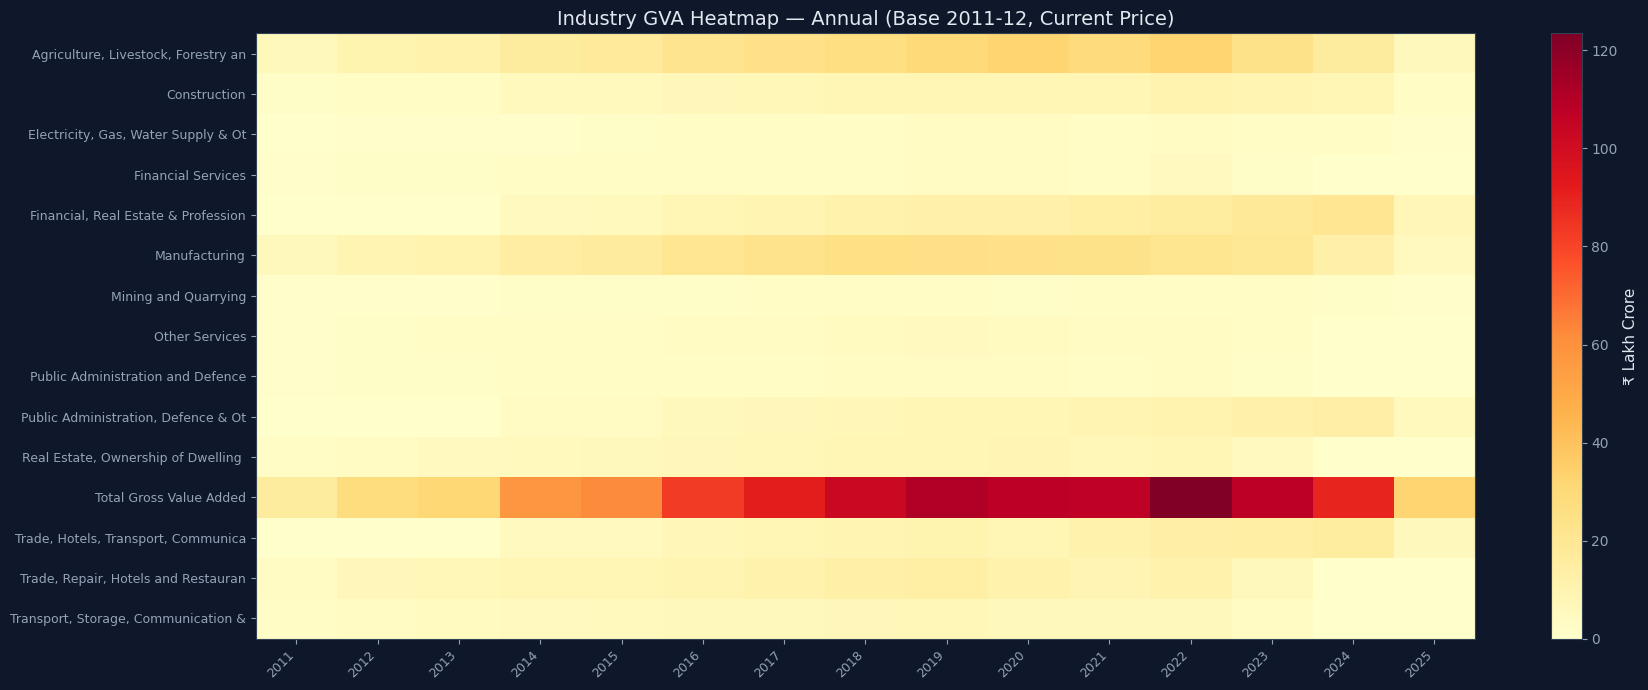

In [13]:
gva_pivot = gva.groupby(['year_int','industry'])['current_price'].sum().unstack('industry') / 1e6
gva_pivot = gva_pivot.fillna(0)

fig, ax = plt.subplots(figsize=(18, 7))
import matplotlib.colors as mcolors
cmap = plt.cm.YlOrRd
im = ax.imshow(gva_pivot.T.values, aspect='auto', cmap=cmap)
ax.set_xticks(range(len(gva_pivot.index)))
ax.set_xticklabels(gva_pivot.index, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(gva_pivot.columns)))
ax.set_yticklabels([c[:35] for c in gva_pivot.columns], fontsize=9)
plt.colorbar(im, ax=ax, label='₹ Lakh Crore')
ax.set_title('Industry GVA Heatmap — Annual (Base 2011-12, Current Price)', fontsize=14)
plt.tight_layout()
plt.savefig('gva_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

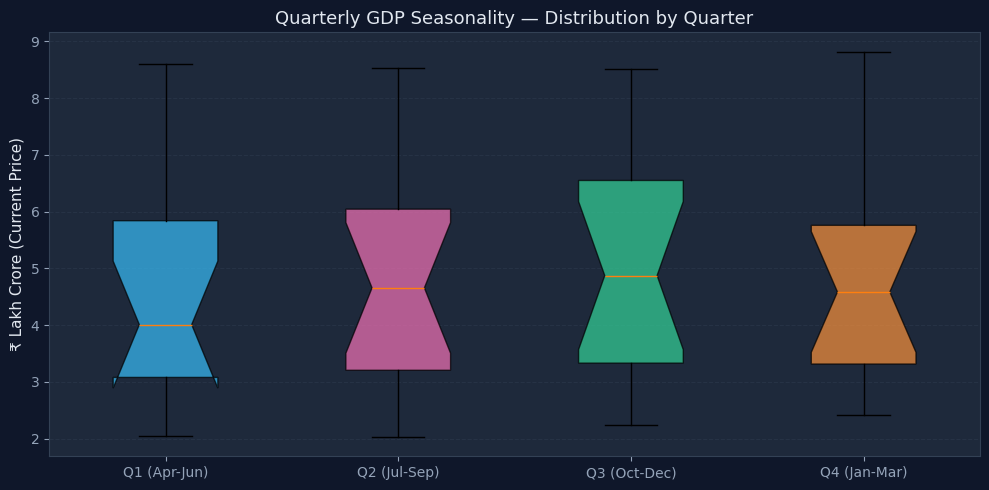

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
q_groups = [gdp_q[gdp_q['quarter'] == q]['current_price'].dropna() / 1e6
            for q in ['Q1','Q2','Q3','Q4']]
bp = ax.boxplot(q_groups, labels=['Q1 (Apr-Jun)','Q2 (Jul-Sep)','Q3 (Oct-Dec)','Q4 (Jan-Mar)'],
                patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Quarterly GDP Seasonality — Distribution by Quarter', fontsize=13)
ax.set_ylabel('₹ Lakh Crore (Current Price)')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('quarterly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

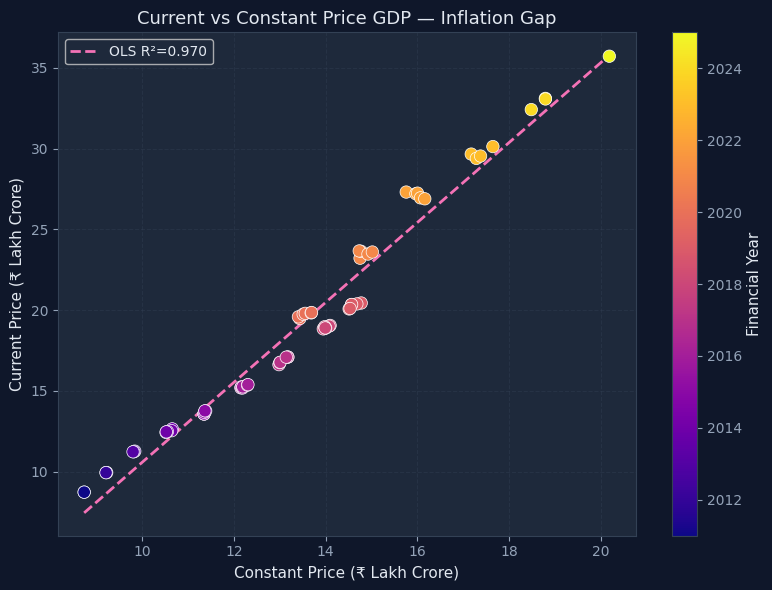

In [15]:
gdp_scatter = df_ann[(df_ann['indicator'] == 'Gross Domestic Product') &
                     (df_ann['base_year'] == '2011-12')].dropna(subset=['current_price','constant_price'])

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(gdp_scatter['constant_price']/1e6,
                gdp_scatter['current_price']/1e6,
                c=gdp_scatter['year_int'], cmap='plasma', s=80, edgecolors='white', lw=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='Financial Year')
ax.set_xlabel('Constant Price (₹ Lakh Crore)')
ax.set_ylabel('Current Price (₹ Lakh Crore)')
ax.set_title('Current vs Constant Price GDP — Inflation Gap', fontsize=13)

x = gdp_scatter['constant_price'].values.reshape(-1,1)
y = gdp_scatter['current_price'].values
from sklearn.linear_model import LinearRegression
m = LinearRegression().fit(x, y)
xl = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
ax.plot(xl/1e6, m.predict(xl)/1e6, '--', color=PALETTE[1], lw=2, label=f'OLS R²={m.score(x,y):.3f}')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('current_vs_constant.png', dpi=150, bbox_inches='tight')
plt.show()

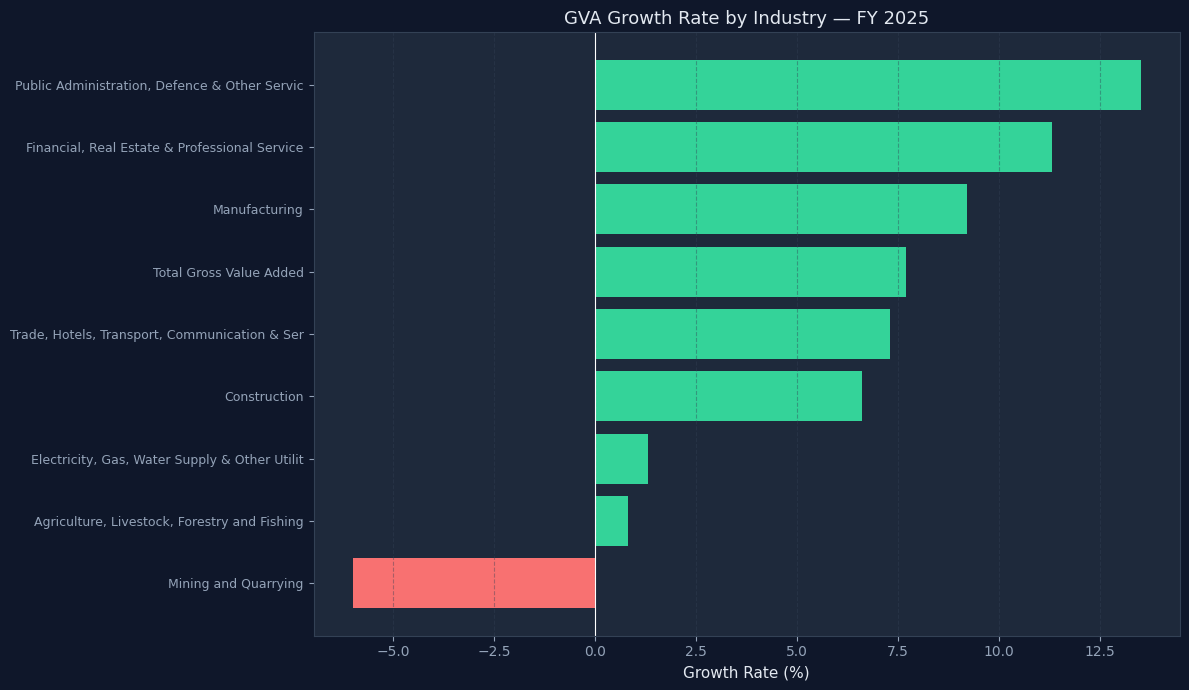

In [16]:
gva_gr = df_rate[(df_rate['indicator'] == 'GVA Growth Rate') &
                 (df_rate['frequency'] == 'Annual') &
                 (df_rate['base_year'] == '2011-12')].dropna(subset=['industry'])

latest2 = gva_gr['year_int'].max()
gva_gr_l = gva_gr[gva_gr['year_int'] == latest2].groupby('industry')['current_price'].mean().sort_values()

if not gva_gr_l.empty:
    fig, ax = plt.subplots(figsize=(12, 7))
    colors2 = [PALETTE[2] if v >= 0 else PALETTE[6] for v in gva_gr_l.values]
    ax.barh(range(len(gva_gr_l)), gva_gr_l.values, color=colors2)
    ax.set_yticks(range(len(gva_gr_l)))
    ax.set_yticklabels([t[:45] for t in gva_gr_l.index], fontsize=9)
    ax.axvline(0, color='white', lw=0.8)
    ax.set_xlabel('Growth Rate (%)')
    ax.set_title(f'GVA Growth Rate by Industry — FY {latest2}', fontsize=13)
    ax.grid(axis='x', alpha=0.4)
    plt.tight_layout()
    plt.savefig('gva_growth_industry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No GVA Growth Rate by industry available')

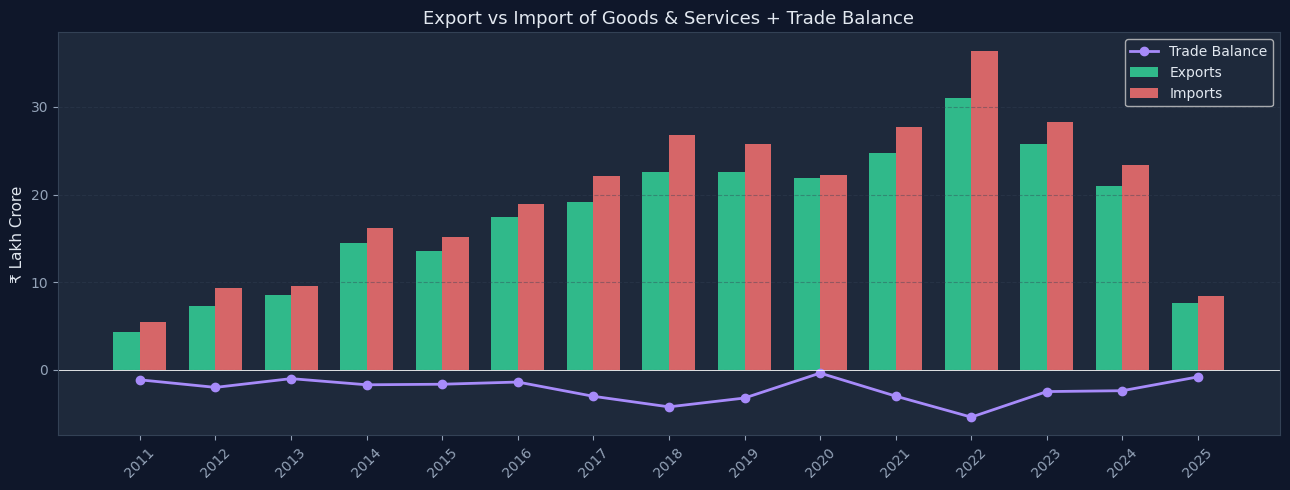

In [17]:
exp = df_ann[(df_ann['indicator'] == 'Export of Goods and Services') & (df_ann['base_year'] == '2011-12')]
imp = df_ann[(df_ann['indicator'] == 'Import of Goods and Services') & (df_ann['base_year'] == '2011-12')]

exp = exp.sort_values('year_int')
imp = imp.sort_values('year_int')
common_yrs = sorted(set(exp['year_int']) & set(imp['year_int']))

exp_v = exp[exp['year_int'].isin(common_yrs)].groupby('year_int')['current_price'].sum() / 1e6
imp_v = imp[imp['year_int'].isin(common_yrs)].groupby('year_int')['current_price'].sum() / 1e6

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(common_yrs))
w = 0.35
ax.bar(x - w/2, exp_v.values, w, label='Exports', color=PALETTE[2], alpha=0.85)
ax.bar(x + w/2, imp_v.values, w, label='Imports', color=PALETTE[6], alpha=0.85)
ax.plot(x, exp_v.values - imp_v.values, 'o-', color=PALETTE[4], lw=2, ms=6, label='Trade Balance')
ax.axhline(0, color='white', lw=0.6)
ax.set_xticks(x)
ax.set_xticklabels(common_yrs, rotation=45)
ax.set_ylabel('₹ Lakh Crore')
ax.set_title('Export vs Import of Goods & Services + Trade Balance', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('trade_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 📈 5. Plotly — Interactive / Real-Time Dashboard Visualisations

In [18]:
gdp_all = df_ann[(df_ann['indicator'] == 'Gross Domestic Product') &
                 (df_ann['base_year'] == '2011-12')].sort_values('year_int')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=gdp_all['year_int'], y=gdp_all['current_price']/1e6,
    mode='lines+markers', name='Current Price',
    line=dict(color='#38bdf8', width=3),
    marker=dict(size=8),
    hovertemplate='FY: %{x}<br>GDP: ₹%{y:.2f} Lakh Crore<extra></extra>'
))
fig.add_trace(go.Scatter(
    x=gdp_all['year_int'], y=gdp_all['constant_price']/1e6,
    mode='lines+markers', name='Constant Price',
    line=dict(color='#f472b6', width=3, dash='dash'),
    marker=dict(size=8),
    hovertemplate='FY: %{x}<br>GDP: ₹%{y:.2f} Lakh Crore<extra></extra>'
))
fig.update_layout(
    title='🇮🇳 India Annual GDP — Interactive (Base 2011-12)',
    xaxis_title='Financial Year',
    yaxis_title='₹ Lakh Crore',
    hovermode='x unified',
    legend=dict(orientation='h', y=-0.2),
    template='plotly_dark',
    height=480
)
fig.show()
fig.write_html('plotly_gdp_trend.html')

In [19]:
gva_anim = gva.groupby(['year_int','industry'])['current_price'].sum().reset_index()
gva_anim = gva_anim.sort_values(['year_int','current_price'], ascending=[True, False])

fig = px.bar(
    gva_anim.dropna(subset=['industry']),
    x='current_price', y='industry', color='industry',
    animation_frame='year_int',
    orientation='h',
    title='🏭 Sectoral GVA — Animated Bar Chart by Year',
    labels={'current_price': '₹ Crore (Current Price)', 'industry': 'Industry'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    template='plotly_dark',
    height=600
)
fig.update_layout(showlegend=False, yaxis={'categoryorder': 'total ascending'})
fig.show()
fig.write_html('plotly_gva_bar_race.html')

In [20]:
gva_latest2 = gva[gva['year_int'] == gva['year_int'].max()].dropna(subset=['industry'])
gva_tm = gva_latest2.groupby('industry')['current_price'].sum().reset_index()
gva_tm = gva_tm[gva_tm['current_price'] > 0]

fig = px.treemap(
    gva_tm,
    path=[px.Constant('India Economy'), 'industry'],
    values='current_price',
    color='current_price',
    color_continuous_scale='RdYlGn',
    title=f'🗺️ Economy Structure Treemap — GVA by Industry (Latest Year)',
    template='plotly_dark',
    height=600
)
fig.show()
fig.write_html('plotly_treemap.html')

In [21]:
gdp_q2 = df_qtr[(df_qtr['indicator'] == 'Gross Domestic Product') &
                (df_qtr['base_year'] == '2011-12')].dropna(subset=['quarter'])
gdp_q2 = gdp_q2.sort_values(['year_int','quarter'])
gdp_q2['period'] = gdp_q2['year_int'].astype(str) + '-' + gdp_q2['quarter'].astype(str)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3],
                    subplot_titles=['Quarterly GDP Level (₹ L Crore)', 'QoQ Change'])

fig.add_trace(go.Scatter(
    x=gdp_q2['period'], y=gdp_q2['current_price']/1e6,
    mode='lines+markers', name='Current',
    line=dict(color='#38bdf8', width=2)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=gdp_q2['period'], y=gdp_q2['constant_price']/1e6,
    mode='lines+markers', name='Constant',
    line=dict(color='#f472b6', width=2, dash='dot')
), row=1, col=1)

gdp_q2['qoq'] = gdp_q2['current_price'].pct_change() * 100
clr = ['#34d399' if v >= 0 else '#f87171' for v in gdp_q2['qoq'].fillna(0)]
fig.add_trace(go.Bar(
    x=gdp_q2['period'], y=gdp_q2['qoq'],
    marker_color=clr, name='QoQ %'
), row=2, col=1)

fig.update_layout(
    title='📊 Quarterly GDP Dashboard (Base 2011-12)',
    template='plotly_dark', height=650, hovermode='x unified'
)
fig.show()
fig.write_html('plotly_quarterly_dashboard.html')

In [22]:
gva_hier = df_ann[(df_ann['indicator'] == 'Gross Value Added') &
                  (df_ann['base_year'] == '2011-12') &
                  (df_ann['year_int'] == gva['year_int'].max())]
gva_hier = gva_hier.dropna(subset=['industry'])
gva_hier['subindustry'] = gva_hier['subindustry'].fillna('Total')
gva_hier_g = gva_hier.groupby(['industry','subindustry'])['current_price'].sum().reset_index()
gva_hier_g = gva_hier_g[gva_hier_g['current_price'] > 0]

fig = px.sunburst(
    gva_hier_g,
    path=['industry','subindustry'],
    values='current_price',
    color='current_price',
    color_continuous_scale='Plasma',
    title='☀️ Sunburst — Industry & Sub-industry GVA Breakdown',
    template='plotly_dark',
    height=650
)
fig.show()
fig.write_html('plotly_sunburst.html')

In [23]:
exp_inds = [
    'Private Final Consumption Expenditure',
    'Government Final Consumption Expenditure',
    'Gross Fixed Capital Formation',
    'Export of Goods and Services',
    'Change in Stock',
]

exp_df_list = []
for ind in exp_inds:
    sub = df_ann[(df_ann['indicator'] == ind) & (df_ann['base_year'] == '2011-12')]
    sub = sub.groupby('year_int')['current_price'].sum().reset_index()
    sub['indicator'] = ind
    exp_df_list.append(sub)

exp_combined = pd.concat(exp_df_list)

fig = px.area(
    exp_combined.dropna(),
    x='year_int', y='current_price',
    color='indicator',
    title='💸 Expenditure Side GDP Components — Stacked Area',
    labels={'current_price': '₹ Crore', 'year_int': 'Financial Year'},
    color_discrete_sequence=px.colors.qualitative.Vivid,
    template='plotly_dark',
    height=500
)
fig.show()
fig.write_html('plotly_expenditure_stacked.html')

In [24]:
gdp_gr_w = df_rate[(df_rate['indicator'] == 'GDP Growth Rate') &
                   (df_rate['frequency'] == 'Annual') &
                   (df_rate['base_year'] == '2011-12')]
gdp_gr_w = gdp_gr_w.groupby('year_int')['current_price'].mean().reset_index().sort_values('year_int')

measure = ['relative'] * len(gdp_gr_w)
clr_wf = ['#34d399' if v >= 0 else '#f87171' for v in gdp_gr_w['current_price']]

fig = go.Figure(go.Waterfall(
    x=gdp_gr_w['year_int'].astype(str),
    y=gdp_gr_w['current_price'],
    measure=measure,
    connector=dict(line=dict(color='#94a3b8')),
    decreasing=dict(marker=dict(color='#f87171')),
    increasing=dict(marker=dict(color='#34d399')),
    totals=dict(marker=dict(color='#facc15')),
    text=[f'{v:.1f}%' for v in gdp_gr_w['current_price']],
    textposition='outside'
))
fig.update_layout(
    title='📉 GDP Growth Rate Waterfall Chart (Annual)',
    yaxis_title='Growth Rate (%)',
    template='plotly_dark',
    height=500
)
fig.show()
fig.write_html('plotly_waterfall.html')

In [25]:
gva_b  = df_ann[(df_ann['indicator'] == 'Gross Value Added') & (df_ann['base_year'] == '2011-12')]
gfcf_b = df_ann[(df_ann['indicator'] == 'Gross Fixed Capital Formation') & (df_ann['base_year'] == '2011-12')]
gr_b   = df_rate[(df_rate['indicator'] == 'GDP Growth Rate') & (df_rate['base_year'] == '2011-12')]

gva_yr  = gva_b.groupby('year_int')['current_price'].sum().rename('gva')
gfcf_yr = gfcf_b.groupby('year_int')['current_price'].sum().rename('gfcf')
gr_yr   = gr_b.groupby('year_int')['current_price'].mean().rename('growth_rate')

bubble = pd.concat([gva_yr, gfcf_yr, gr_yr], axis=1).dropna().reset_index()

fig = px.scatter(
    bubble, x='gfcf', y='gva', size=bubble['growth_rate'].abs(),
    color='growth_rate', color_continuous_scale='RdYlGn',
    text='year_int', hover_name='year_int',
    labels={'gfcf': 'GFCF (₹ Crore)', 'gva': 'GVA (₹ Crore)', 'growth_rate': 'GDP Growth %'},
    title='🫧 Bubble Chart — GFCF vs GVA, sized by GDP Growth Rate',
    template='plotly_dark', height=550
)
fig.update_traces(textposition='top center')
fig.show()
fig.write_html('plotly_bubble.html')

In [26]:
gdp_rev = df_ann[(df_ann['indicator'] == 'Gross Domestic Product') &
                 (df_ann['base_year'] == '2011-12')].dropna(subset=['revision'])
gdp_rev = gdp_rev.groupby(['year_int','revision'])['current_price'].mean().reset_index()

fig = px.line(
    gdp_rev, x='year_int', y='current_price', color='revision',
    markers=True,
    title='📋 GDP Estimate Revisions — How Estimates Change Over Time',
    labels={'current_price': '₹ Crore', 'year_int': 'FY', 'revision': 'Revision Type'},
    template='plotly_dark', height=500
)
fig.show()
fig.write_html('plotly_revisions.html')

In [27]:
radar_inds = [
    'Private Final Consumption Expenditure',
    'Government Final Consumption Expenditure',
    'Gross Fixed Capital Formation',
    'Export of Goods and Services',
    'Gross Saving',
    'Gross National Income',
]

radar_vals = []
for ind in radar_inds:
    sub = df_ann[(df_ann['indicator'] == ind) & (df_ann['base_year'] == '2011-12')]
    latest_v = sub[sub['year_int'] == sub['year_int'].max()]['current_price'].sum()
    radar_vals.append(latest_v / 1e6)

fig = go.Figure(go.Scatterpolar(
    r=radar_vals, theta=radar_inds, fill='toself',
    line=dict(color='#38bdf8'), fillcolor='rgba(56,189,248,0.2)'
))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, color='#94a3b8')),
    title='🕸️ Macro Indicator Radar — Latest Year (₹ Lakh Crore)',
    template='plotly_dark',
    height=550
)
fig.show()
fig.write_html('plotly_radar.html')

In [28]:
pc_df = df_ann[(df_ann['base_year'] == '2011-12')]\
    .pivot_table(index='year_int', columns='indicator',
                 values='current_price', aggfunc='sum').reset_index()
pc_df = pc_df[['year_int'] + [c for c in [
    'Gross Domestic Product', 'Gross Value Added',
    'Gross Fixed Capital Formation',
    'Private Final Consumption Expenditure',
    'Export of Goods and Services',
] if c in pc_df.columns]].dropna()

fig = px.parallel_coordinates(
    pc_df, color='year_int',
    color_continuous_scale='Viridis',
    dimensions=[c for c in pc_df.columns if c != 'year_int'],
    title='🔗 Parallel Coordinates — Key Macro Indicators by Year',
    template='plotly_dark',
    height=500
)
fig.show()
fig.write_html('plotly_parallel_coords.html')

## 🤖 6. Machine Learning — GDP Forecasting Model

In [29]:
gdp_ml = df_ann[(df_ann['indicator'] == 'Gross Domestic Product') &
                (df_ann['base_year'] == '2011-12')].copy()
gdp_ml = gdp_ml.dropna(subset=['current_price','constant_price'])
gdp_ml = gdp_ml.groupby('year_int').agg(
    current_price=('current_price','mean'),
    constant_price=('constant_price','mean')
).reset_index().sort_values('year_int')

gdp_ml['lag1_cp']    = gdp_ml['current_price'].shift(1)
gdp_ml['lag2_cp']    = gdp_ml['current_price'].shift(2)
gdp_ml['lag1_const'] = gdp_ml['constant_price'].shift(1)
gdp_ml['growth_rate_cp'] = gdp_ml['current_price'].pct_change() * 100
gdp_ml['deflator']   = gdp_ml['current_price'] / gdp_ml['constant_price']
gdp_ml = gdp_ml.dropna()

feature_cols = ['year_int','lag1_cp','lag2_cp','lag1_const','growth_rate_cp','deflator']
X = gdp_ml[feature_cols].values
y = gdp_ml['current_price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (9, 6), Test: (4, 6)


In [30]:
from sklearn.linear_model import Ridge
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42)
}

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'rmse': rmse, 'r2': r2}
    print(f'{name:25s}  RMSE: {rmse:>15,.0f}  R²: {r2:.4f}')

Linear Regression          RMSE:         466,918  R²: 0.9965
Ridge Regression           RMSE:       1,384,917  R²: 0.9694
Gradient Boosting          RMSE:       1,926,392  R²: 0.9408
Random Forest              RMSE:       1,951,541  R²: 0.9392


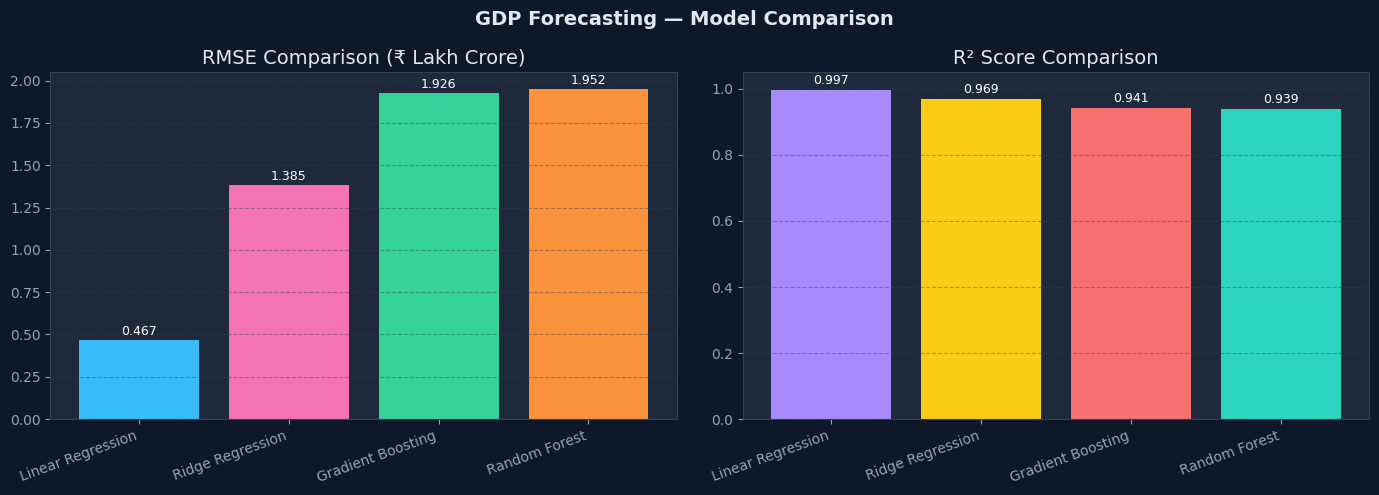

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(results.keys())
rmses = [results[n]['rmse'] for n in names]
r2s   = [results[n]['r2']   for n in names]

axes[0].bar(names, [r/1e6 for r in rmses], color=PALETTE[:4])
axes[0].set_title('RMSE Comparison (₹ Lakh Crore)')
axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].grid(axis='y', alpha=0.4)

axes[1].bar(names, r2s, color=PALETTE[4:8])
axes[1].set_title('R² Score Comparison')
axes[1].set_xticklabels(names, rotation=20, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.4)

for ax in axes:
    for bar in ax.patches:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9, color='white')

fig.suptitle('GDP Forecasting — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

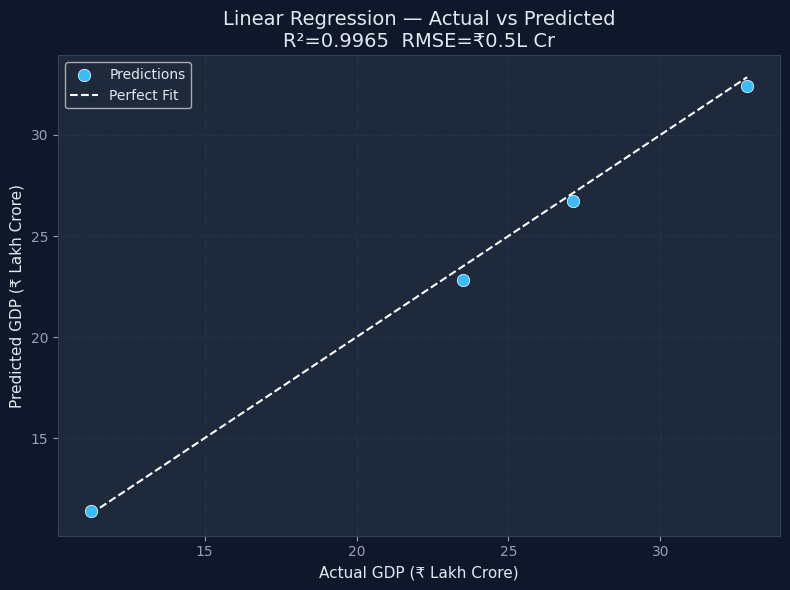

Best model: Linear Regression


In [32]:
best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test/1e6, best['preds']/1e6, color=PALETTE[0], s=80,
           edgecolors='white', lw=0.5, zorder=3, label='Predictions')
mn, mx = min(y_test.min(), best['preds'].min())/1e6, max(y_test.max(), best['preds'].max())/1e6
ax.plot([mn, mx], [mn, mx], '--', color='white', lw=1.5, label='Perfect Fit')
ax.set_xlabel('Actual GDP (₹ Lakh Crore)')
ax.set_ylabel('Predicted GDP (₹ Lakh Crore)')
ax.set_title(f'{best_name} — Actual vs Predicted\nR²={best["r2"]:.4f}  RMSE=₹{best["rmse"]/1e6:.1f}L Cr')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best model: {best_name}')

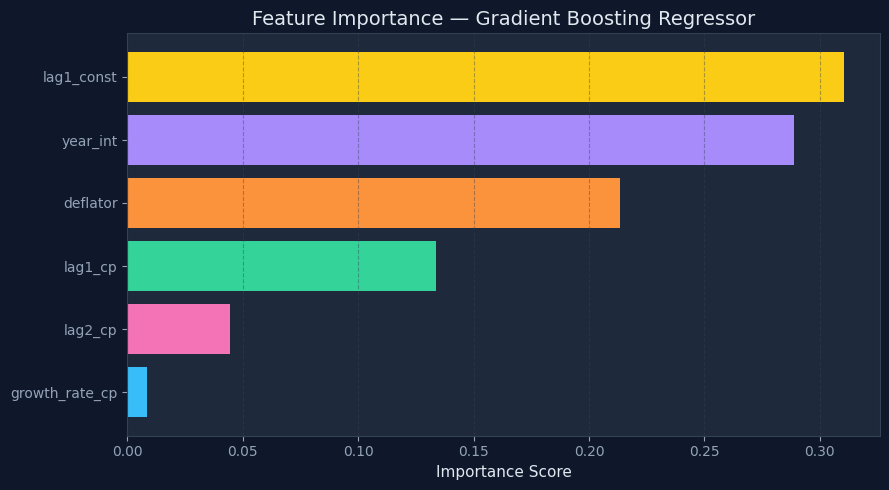

In [33]:
gb_model = results['Gradient Boosting']['model']
fi = pd.Series(gb_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi.index, fi.values, color=PALETTE[:len(fi)])
ax.set_title('Feature Importance — Gradient Boosting Regressor')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
best_model = results[best_name]['model']
last_row   = gdp_ml.iloc[-1]

forecast_rows = []
cp   = last_row['current_price']
cst  = last_row['constant_price']
l1   = last_row['lag1_cp']
yr   = int(last_row['year_int'])
defl = last_row['deflator']

for i in range(1, 4):
    yr_new   = yr + i
    gr_est   = gdp_ml['growth_rate_cp'].mean()
    defl_est = defl * 1.05
    feat = np.array([[yr_new, cp, l1, cst, gr_est, defl_est]])
    feat_s = scaler.transform(feat)
    pred_cp = best_model.predict(feat_s)[0]
    forecast_rows.append({'year_int': yr_new, 'predicted_gdp': pred_cp, 'type': 'Forecast'})
    l1, cp = cp, pred_cp

forecast_df = pd.DataFrame(forecast_rows)
historical_plot = gdp_ml[['year_int','current_price']].copy()
historical_plot['type'] = 'Historical'
historical_plot = historical_plot.rename(columns={'current_price':'predicted_gdp'})
combined = pd.concat([historical_plot, forecast_df])

fig = go.Figure()
hist = combined[combined['type']=='Historical']
fore = combined[combined['type']=='Forecast']

fig.add_trace(go.Scatter(
    x=hist['year_int'], y=hist['predicted_gdp']/1e6,
    mode='lines+markers', name='Historical GDP',
    line=dict(color='#38bdf8', width=3)
))
fig.add_trace(go.Scatter(
    x=fore['year_int'], y=fore['predicted_gdp']/1e6,
    mode='lines+markers', name='Forecast',
    line=dict(color='#facc15', width=3, dash='dash'),
    marker=dict(size=12, symbol='star')
))
fig.update_layout(
    title=f'🔮 GDP Forecast — Next 3 Years (using {best_name})',
    xaxis_title='Financial Year',
    yaxis_title='₹ Lakh Crore',
    template='plotly_dark', height=480, hovermode='x unified'
)
fig.show()
fig.write_html('plotly_gdp_forecast.html')
print('Forecasts (₹ Crore):')
print(forecast_df[['year_int','predicted_gdp']].to_string(index=False))

Forecasts (₹ Crore):
 year_int  predicted_gdp
     2026   3.880481e+07
     2027   4.266114e+07
     2028   4.748572e+07


## 📦 7. Summary of Generated Assets

In [35]:
import os
print('=== Generated Files ===')
for f in sorted(os.listdir('.')):
    if f.endswith(('.png','.html')):
        size = os.path.getsize(f)
        print(f'  {f:45s}  {size/1024:.1f} KB')

print()
print('=== Best Model Summary ===')
for name, res in results.items():
    print(f'{name:30s}  R²={res["r2"]:.4f}  RMSE=₹{res["rmse"]/1e6:.1f}L Cr')

=== Generated Files ===
  ._actual_vs_predicted.png                      4.0 KB
  ._current_vs_constant.png                      4.0 KB
  ._feature_importance.png                       4.0 KB
  ._gdp_annual_trend.png                         4.0 KB
  ._gdp_growth_bars.png                          4.0 KB
  ._gdp_quarterly.png                            4.0 KB
  ._gva_growth_industry.png                      4.0 KB
  ._gva_heatmap.png                              4.0 KB
  ._gva_sectoral.png                             4.0 KB
  ._macro_indicators.png                         4.0 KB
  ._missing_values.png                           4.0 KB
  ._model_comparison.png                         4.0 KB
  ._plotly_bubble.html                           4.0 KB
  ._plotly_expenditure_stacked.html              4.0 KB
  ._plotly_gdp_forecast.html                     4.0 KB
  ._plotly_gdp_trend.html                        4.0 KB
  ._plotly_gva_bar_race.html                     4.0 KB
  ._plotly_parallel_coor